In [ ]:
import torch
from neuronav.envs.graph_env import GraphObservation

from rtrv_models.DQN4Maze.train import train_dqn
from rtrv_models.DQN4Maze.graph import CustomGraphEnv, maze1_graph
from rtrv_models.DQN4Maze.utils import (
    MazeRewards,
    build_allocentric_edges,
    make_reward_table_allocentric,
)
from rtrv_models.DQN4Maze.wrappers import GoalTerminateWrapper, StartReturnPenaltyWrapper


# Reward config (allocentric baseline: state=node, actions=N/E/S/W).
rewards = MazeRewards(goal_reward=1.0, dead_end_punish=-0.2, step_cost=0.0)

# Build allocentric transitions and rewards.
edges = build_allocentric_edges(maze1_graph, width=12)
reward_table = make_reward_table_allocentric(
    maze1_graph,
    start_node=1,
    goal_node=144,
    rewards=rewards,
)
objects = {"rewards": reward_table}

start_state = 0  # node 1 -> state 0

env = CustomGraphEnv(objects=objects, edges=edges,
                     obs_type=GraphObservation.index)
env = GoalTerminateWrapper(env, goal_state=143)

# Add start-return punishment.
env = StartReturnPenaltyWrapper(
    env,
    start_state=start_state,
    penalty=-0.1,
)

logs, agent, records = train_dqn(
    env=env,
    start_state=0,
    warmup=5000,
    train_every=1,
    batch_size=128,
    buffer_size=20000,
    eps_start=1.0,
    eps_end=0.02,
    max_ep_len=40000,
    n_steps=200000,
    eps_decay_steps=400000,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

print("Episodes:", len(logs["episode_return"]))
print("Last 10 returns:", logs["episode_return"][-10:])

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


[   2000/200000]  eps=0.995  buf=   2000  R50=    nan  L50=   nan  loss200=     nan  lr=1.0e-03   1539.1 steps/s  t=   1.3s  last: s= 84(n= 85) a= W s'= 72(n= 73) wall=0
[   4000/200000]  eps=0.990  buf=   4000  R50=    nan  L50=   nan  loss200=     nan  lr=1.0e-03   4392.3 steps/s  t=   1.8s  last: s= 46(n= 47) a= S s'= 47(n= 48) wall=0
[   6000/200000]  eps=0.985  buf=   6000  R50=    nan  L50=   nan  loss200=4371.43256897  lr=1.0e-03    705.4 steps/s  t=   4.6s  last: s= 27(n= 28) a= W s'= 15(n= 16) wall=0
[   8000/200000]  eps=0.980  buf=   8000  R50=    nan  L50=   nan  loss200=359775.08398438  lr=1.0e-03    472.1 steps/s  t=   8.8s  last: s= 53(n= 54) a= N s'= 52(n= 53) wall=0
[  10000/200000]  eps=0.976  buf=  10000  R50=    nan  L50=   nan  loss200=2502334.66750000  lr=1.0e-03    459.7 steps/s  t=  13.2s  last: s= 62(n= 63) a= E s'= 74(n= 75) wall=0
[  12000/200000]  eps=0.971  buf=  12000  R50=    nan  L50=   nan  loss200=9265249.77750000  lr=1.0e-03    445.1 steps/s  t=  17.7

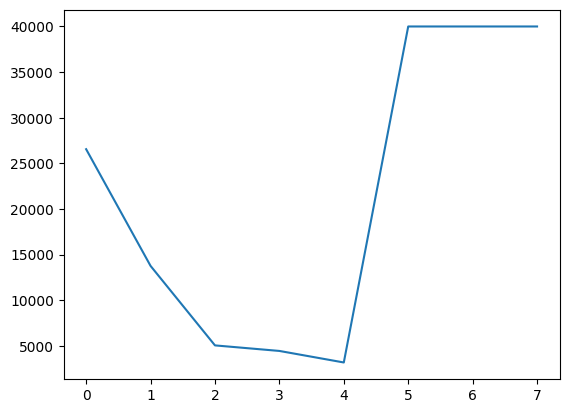

[-0.2 -0.1 -0.2 ...  0.   0.   1. ]


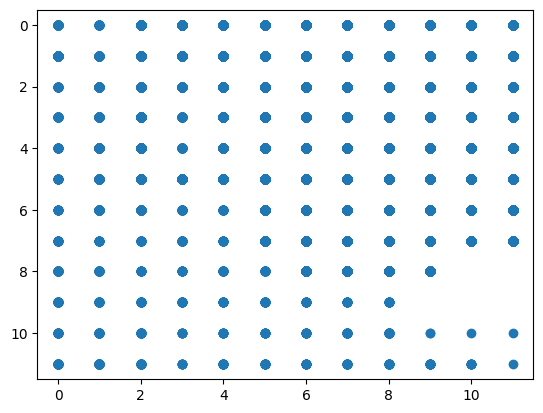

[-0.2 -0.1 -0.2 ...  0.   0.   1. ]


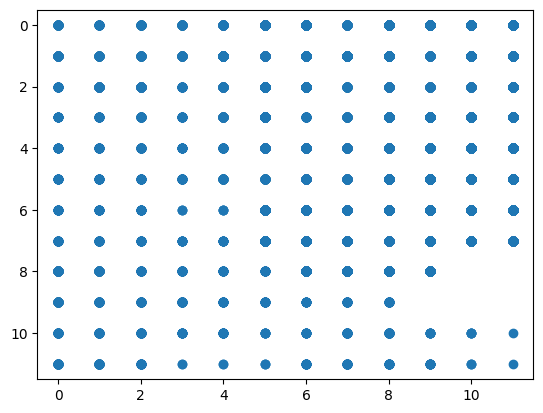

[-0.2 -0.1  0.  ...  0.   0.   1. ]


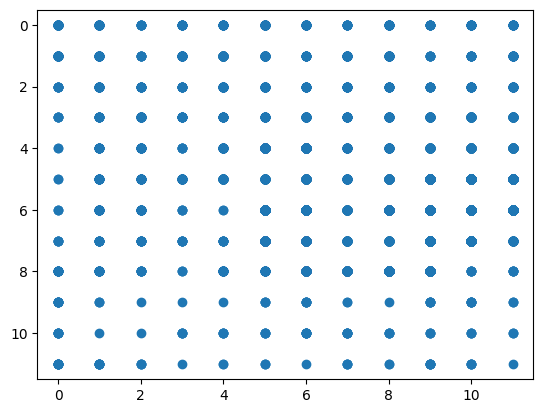

[-0.2 -0.1  0.  ...  0.   0.   1. ]


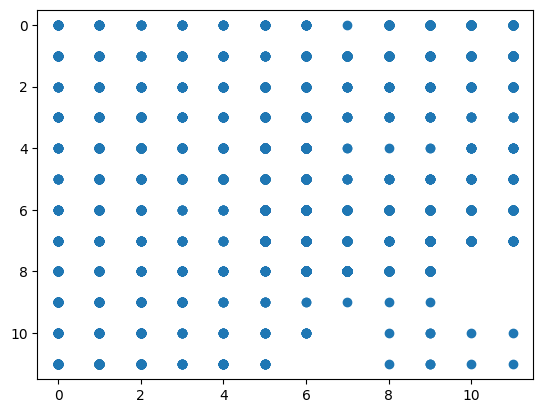

[0. 0. 0. ... 0. 0. 1.]


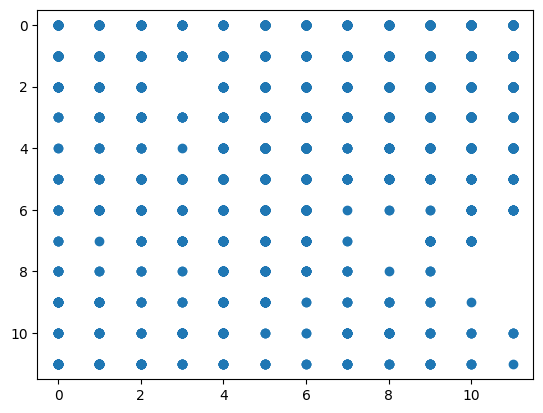

[0. 0. 0. ... 0. 0. 0.]


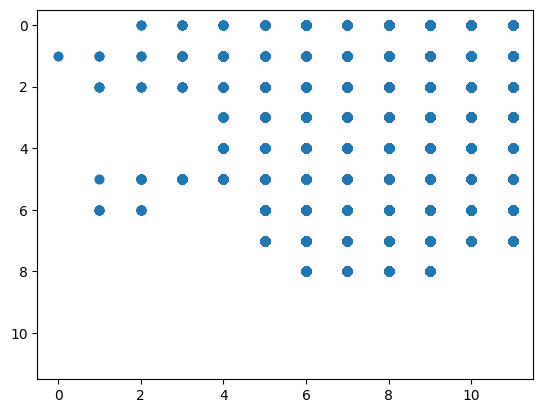

[0. 0. 0. ... 0. 0. 0.]


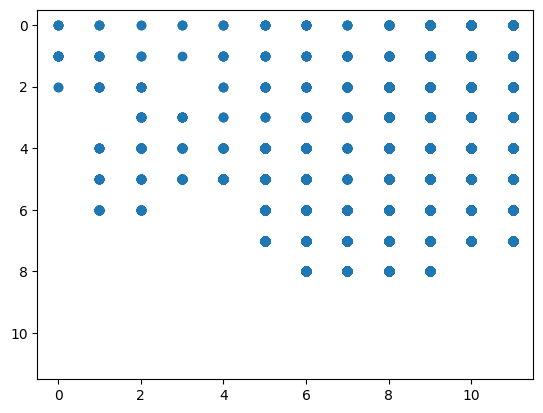

[-0.2 -0.1 -0.2 ...  0.   0.   0. ]


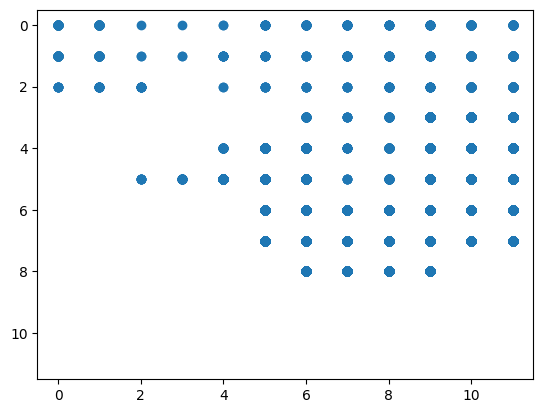

In [5]:
import numpy as np
import matplotlib.pyplot as plt

n_steps = [len(records[i]) for i in range(len(records))]
plt.plot(n_steps)
plt.show()

for j in range(len(records)):
    nodes = np.array([records[j][i][1] for i in range(len(records[j]))])
    print(np.array([records[j][i][3] for i in range(len(records[j]))]))
    x, y = nodes % 12, nodes // 12

    ax = plt.gca()
    ax.scatter(x, y)
    ax.set_xlim([-0.5, 11.5])
    ax.set_ylim([-0.5, 11.5])
    ax.invert_yaxis()
    plt.show()

In [5]:
import pickle
import os

with open("dqn_agent.pkl", "wb") as f:
    pickle.dump(agent, f)

In [ ]:
import pickle

import numpy as np
import torch
from neuronav.envs.graph_env import GraphObservation

from rtrv_models.DQN4Maze.evaluate import (
    rollout_greedy_alloc,
)
from rtrv_models.DQN4Maze.graph import CustomGraphEnv, maze1_graph
from rtrv_models.DQN4Maze.utils import (
    MazeRewards,
    build_allocentric_edges,
    make_reward_table_allocentric,
)
from rtrv_models.DQN4Maze.wrappers import GoalTerminateWrapper, StepCostWrapper


# Reward config (allocentric baseline: state=node, actions=N/E/S/W).
rewards = MazeRewards(goal_reward=1.0, dead_end_punish=-0.2, step_cost=0.0)

# Build allocentric transitions and rewards.
edges = build_allocentric_edges(maze1_graph, width=12)
reward_table = make_reward_table_allocentric(
    maze1_graph,
    start_node=0,
    goal_node=143,
    rewards=rewards,
)
objects = {"rewards": reward_table}

# Instantiate Neuro-Nav env with integer observations (state index).
env = CustomGraphEnv(
    objects=objects,
    edges=edges,
    obs_type=GraphObservation.index,
)

# Terminate when reaching the goal (state index = goal_node - 1).
env = GoalTerminateWrapper(env, goal_state=144 - 1)

# Optional step cost shaping.
if rewards.step_cost != 0.0:
    env = StepCostWrapper(env, step_cost=rewards.step_cost)

# Allocentric start state is just node index (0-based).
start_state = 1 - 1

# Load the trained agent.
with open("dqn_agent.pkl", "rb") as f:
    agent = pickle.load(f)

goal_state = 144 - 1
out = rollout_greedy_alloc(env, agent, start_state, goal_state)
print("Reached goal:", bool(out["reached_goal"]))
print("Done:", bool(out["done"]))
print("Steps:", int(out["actions"].size))
print("Visited goal:", bool(np.any(out["states"] == goal_state)))

obs = int(env.reset(agent_pos=start_state))
print("Start obs:", obs)

from typing import Any, Tuple, Optional

from collections import deque
from typing import Dict, List
import numpy as np


def bfs_distances(
    maze_graph: Dict[int, List[int]],
    src_node: int,
) -> np.ndarray:
    """Compute shortest-path distance from src_node to all nodes.

    Parameters
    ----------
    maze_graph
        Adjacency dict with 1-based node ids.
    src_node
        Source node id (1-based).

    Returns
    -------
    dist
        Array of shape (n_nodes + 1,) with dist[node] in steps.
        dist[0] is unused. Unreachable nodes have dist = -1.

    """
    n_nodes = len(maze_graph)
    dist = -np.ones((n_nodes + 1,), dtype=np.int64)
    q = deque([int(src_node)])
    dist[int(src_node)] = 0

    while q:
        u = q.popleft()
        for v in maze_graph[int(u)]:
            if dist[int(v)] < 0:
                dist[int(v)] = dist[int(u)] + 1
                q.append(int(v))
    return dist

dist_to_goal = bfs_distances(maze1_graph, src_node=goal_state + 1)

def trace_policy_episode(
    env,
    agent,
    start_state: int,
    goal_state: int,
    dist_to_goal: np.ndarray,
    max_steps: int = 5000,
    eps: float = 0.0,
) -> dict:
    """Trace one episode and compute thrashing diagnostics.

    Parameters
    ----------
    env
        Allocentric env where obs is 0-based node index.
    agent
        Agent with act(s, eps).
    start_state
        0-based start state (node-1).
    goal_state
        0-based goal state (node-1).
    dist_to_goal
        dist_to_goal[node] in steps where node is 1-based.
    max_steps
        Max steps to trace.
    eps
        Epsilon for action selection.

    Returns
    -------
    out
        Dict with:
        - "states": 0-based states
        - "actions": actions
        - "done": bool
        - "reached_goal": bool
        - "backtrack_rate": fraction of u->v->u patterns
        - "unique_nodes": number of unique nodes visited
        - "unique_edges": number of unique undirected edges visited
        - "max_depth": max distance from start in tree steps
        - "min_dist_to_goal": best (smallest) dist-to-goal achieved
        - "dist_to_goal_trace": per-step distance-to-goal

    """
    s = int(env.reset(agent_pos=int(start_state)))

    states = [s]
    actions = []
    done = False
    reached_goal = False

    for _ in range(int(max_steps)):
        a = int(agent.act(s, eps=float(eps)))
        s2, r, done, info = env.step(a)
        s2 = int(s2)

        actions.append(a)
        states.append(s2)

        s = s2
        if s == int(goal_state):
            reached_goal = True
        if done:
            break

    st = np.asarray(states, dtype=np.int64)
    ac = np.asarray(actions, dtype=np.int64)

    # Backtrack count: s[t] == s[t-2] for t>=2
    if st.size >= 3:
        backtracks = np.sum(st[2:] == st[:-2])
        backtrack_rate = float(backtracks) / float(st.size - 2)
    else:
        backtrack_rate = 0.0

    # Unique nodes and undirected edges visited.
    nodes1 = st + 1
    uniq_nodes = int(np.unique(nodes1).size)

    edges = []
    for u, v in zip(nodes1[:-1], nodes1[1:]):
        e = (int(u), int(v)) if u < v else (int(v), int(u))
        edges.append(e)
    uniq_edges = int(len(set(edges))) if edges else 0

    # Depth from start in a tree: dist(start, node)
    start_node = int(start_state) + 1
    dist_from_start = bfs_distances(maze1_graph, src_node=start_node)
    depth = dist_from_start[nodes1]
    max_depth = int(np.max(depth)) if depth.size else 0

    # Distance to goal trace.
    dgoal = dist_to_goal[nodes1]
    min_dgoal = int(np.min(dgoal)) if dgoal.size else -1

    return {
        "states": st,
        "actions": ac,
        "done": np.asarray(done, dtype=bool),
        "reached_goal": np.asarray(reached_goal, dtype=bool),
        "backtrack_rate": np.asarray(backtrack_rate, dtype=np.float32),
        "unique_nodes": np.asarray(uniq_nodes, dtype=np.int64),
        "unique_edges": np.asarray(uniq_edges, dtype=np.int64),
        "max_depth": np.asarray(max_depth, dtype=np.int64),
        "min_dist_to_goal": np.asarray(min_dgoal, dtype=np.int64),
        "dist_to_goal_trace": dgoal.astype(np.int64),
    }
    
trace = trace_policy_episode(
    env=env,
    agent=agent,
    start_state=start_state,
    goal_state=goal_state,
    dist_to_goal=dist_to_goal,
    max_steps=40000,
    eps=1,
)

def summarize_trace(trace: dict, prefix: str = "") -> None:
    """Print key diagnostics from a trace."""
    print(prefix + "Reached goal:", bool(trace["reached_goal"]))
    print(prefix + "Steps:", int(trace["actions"].size))
    print(prefix + "Backtrack rate:", float(trace["backtrack_rate"]))
    print(prefix + "Unique nodes:", int(trace["unique_nodes"]))
    print(prefix + "Unique edges:", int(trace["unique_edges"]))
    print(prefix + "Max depth:", int(trace["max_depth"]))
    print(prefix + "Min dist-to-goal:", int(trace["min_dist_to_goal"]))

    ac = trace["actions"]
    if ac.size > 0:
        snippet = ac[:50].tolist()
        print(prefix + "First 50 actions:", snippet)
        
summarize_trace(trace)

obs = int(env.reset(agent_pos=0))
print("Start:", obs)
print("edges[0]:", env.edges[0])
for a in range(env.action_space.n):
    obs2, r, done, info = env.step(a)
    print("a", a, "->", int(obs2), "r", float(r), "done", bool(done))
    env.reset(agent_pos=0)

Reached goal: False
Done: False
Steps: 20000
Visited goal: False
Start obs: 0
Reached goal: True
Steps: 10887
Backtrack rate: 0.3916957676410675
Unique nodes: 139
Unique edges: 273
Max depth: 110
Min dist-to-goal: 0
First 50 actions: [0, 3, 0, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 2, 1, 3, 1, 1, 3, 1, 2, 2, 1, 0, 1, 1, 3, 2, 2, 0, 0, 0, 3, 3, 3, 3, 0, 3, 0, 2, 0, 2, 1, 3, 0, 0, 0, 2, 1, 3]
Start: 0
edges[0]: [0, 12, 1, 0]
a 0 -> 0 r 0.0 done False
a 1 -> 12 r 0.0 done False
a 2 -> 1 r -0.2 done False
a 3 -> 0 r 0.0 done False
